In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

import ml_tools as mlt
import sim_ranking as sr
import spatial_hazard as sh

In [2]:
results_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/ml/0422_0942_cWeights_30_100_weighted")
db_ffp = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/perturbed_0313_100r/gm_db_emp.sqlite")
hp_config_ffp = Path("/Users/claudy/dev/work/code/sim_ranking/sim_ranking/ml_models/sc_prob_config.yaml")
corr_dir = Path("/Users/claudy/dev/work/data/sim_ranking/emp_realisations/event_loth_baker_correlations")

seed = 50

In [3]:
run_config = sr.ml.sc_prob.RunParamsConfig(
    30,
    100,
    sr.constants.IM_SETS["pSA"],
    sr.constants.IM_WEIGTHS_SETS["pSA"],
    True,
    True,
    0.5,
    2.0,
    sr.ml.sc_prob.SampleWeighting.CUSTOM_MODEL,
    False,
    "cpu",
    results_dir=None,
)

hp_config = sr.ml.sc_prob.HyperParamsConfig.from_yaml(hp_config_ffp, 100)
weight_model = torch.load(results_dir / "weight_model.pt", map_location=torch.device('cpu'))

db = sr.db.DB(db_ffp)

In [4]:
events = db.get_avail_events(data_source="emp")
print(f"Number of events: {len(events)}")

# Get all relevant sites across all events
all_sites = db.get_avail_sites()

### Data setup
# Get the sites per event
event_sites = db.get_event_sites()

# Split into training and validation
if seed is not None:
    print(f"Using numpy random seed: {seed}")
    np.random.seed(seed)
val_int_sites = np.random.choice(all_sites, 100, replace=False)
train_sites = np.setdiff1d(all_sites, val_int_sites)

val_events = np.random.choice(events, 75, replace=False)
train_events = np.setdiff1d(events, val_events)

train_dataset, val_dataset, scalar_features, data_metadata = sr.ml.sc_prob.data_prep(
    event_sites,
    train_events,
    val_events,
    train_sites,
    val_int_sites,
    events,
    run_config,
    hp_config,
    db,
    corr_dir=corr_dir,
)

Number of events: 258
Using numpy random seed: 50
Computing distance matrix
Pre-processing site & event features
Computing scalar features
Creating site combinations
Creating datasets


Processing events: 100%|██████████| 75/75 [00:02<00:00, 25.25it/s]

Number of training samples (scenarios): 3204
Number of validation samples (scenarios) : 582


In [36]:
def get_result_df(dataset):
    data_loader = sr.ml.prob.CustomTabularDataLoader(dataset, batch_size=128, shuffle=False, shuffle_rels=False)
    
    weight_cols = [f"{cur_pSA}_weight" for cur_pSA in sr.constants.PSA_KEYS]
    
    results = []
    
    for i, (
        batch_ind,
        rel_shuffle_ind,
        sc_ids,
        sc_im_misfit_score,
        record_scenario_ids,
        site_int_norm_sim_ims,
        site_obs_norm_sim_ims,
        site_obs_norm_obs_ims,
        site_int_sim_ims,
        site_obs_sim_ims,
        site_obs_obs_ims,
        scalar_features,
        w_scalar_features,
        im_misfit_score,
        im_site_corrs,
    ) in enumerate(data_loader):
        (
            events,
            record_events,
            site_int,
            record_site_int,
            site_obs,
            record_site_obs,
            rels,
            residual,
            record_residual,
            n_sites_scenario,
        ) = dataset.get_metadata(batch_ind, rel_shuffle_ind)
        
        w_pred = weight_model(w_scalar_features.to(torch.float32))
        
        cur_result = pd.DataFrame(columns=["event", "site_int", "site_obs"], data={"event": record_events, "site_int": record_site_int, "site_obs": record_site_obs})
        cur_result[weight_cols] =  w_pred.numpy(force=True)
        cur_result[dataset.scalar_features_columns] = scalar_features.numpy(force=True)
        
        cur_result["w_avg"] = cur_result[weight_cols].mean(axis=1)
        
        results.append(cur_result)
        
    result_df = pd.concat(results, axis=0)
    return result_df

In [37]:
train_results_df = get_result_df(train_dataset)
val_results_df = get_result_df(val_dataset)

In [7]:
# Load the station, event data, etc 
station_df = db.get_site_df()
event_df = db.get_event_df()
record_df = db.get_record_df()
dist_matrix = sh.im_dist.calculate_distance_matrix(station_df.index.values.astype(str), station_df)

In [38]:
def get_param_df(result_df):
    param_df = result_df[["event", "site_int", "site_obs"]].copy()
    param_df["mag"] = event_df.loc[param_df["event"].values, "mag"].values
    param_df["vs30_site_int"] = station_df.loc[param_df["site_int"].values, "vs30"].values
    param_df["z1.0_site_int"] = station_df.loc[param_df["site_int"].values, "z1.0"].values
    param_df["z2.5_site_int"] = station_df.loc[param_df["site_int"].values, "z2.5"].values
    param_df["vs30_site_obs"] = station_df.loc[param_df["site_obs"].values, "vs30"].values
    param_df["z1.0_site_obs"] = station_df.loc[param_df["site_obs"].values, "z1.0"].values
    param_df["z2.5_site_obs"] = station_df.loc[param_df["site_obs"].values, "z2.5"].values
    param_df["r_rup_site_int"] = record_df.loc[mlt.array_utils.numpy_str_join("_", param_df.event.values.astype(str), param_df.site_int.values.astype(str)), "r_rup"].values
    param_df["r_rup_site_obs"] = record_df.loc[mlt.array_utils.numpy_str_join("_", param_df.event.values.astype(str), param_df.site_obs.values.astype(str)), "r_rup"].values
    param_df["dist"] = dist_matrix.values[dist_matrix.index.get_indexer_for(param_df.site_int.values), dist_matrix.columns.get_indexer_for(param_df.site_obs.values)]
    param_df["vs30_diff"] = np.abs(param_df.vs30_site_int - param_df.vs30_site_obs)
    return param_df

In [39]:
train_param_df = get_param_df(train_results_df)
val_param_df = get_param_df(val_results_df)

In [11]:
def gen_weight_dist_plot(result_df):
    ims = sr.constants.PSA_KEYS
    
    # Create subplots with shared x-axis
    fig, axs = plt.subplots(int(np.ceil(len(ims) / 2)), 2, figsize=(15, 30), sharex=True)
    
    axs = axs.flatten()
    
    for i, im in enumerate(ims):
        ax = axs[i]
        ax.hist(result_df[f"{im}_weight"], log=True)
        ax.set_xlim(0, 1)
        ax.set_xlabel("Weight")
        ax.set_ylabel("Count" if i % 2 == 0 else "")
        ax.text(0.85, 0.9, f"{im}", horizontalalignment="left", verticalalignment="center", transform=ax.transAxes)
        
        if i % 2 != 0:  # For the second column, remove y-ticks
            ax.set_yticks([])
            ax.set_yticklabels([])
        
    
    fig.tight_layout()
    plt.subplots_adjust(hspace=0, wspace=0)

In [ ]:
print(f"Training Weight Distribution")
gen_weight_dist_plot(train_results_df)

In [ ]:
print(f"Validation Weight Distribution")
gen_weight_dist_plot(val_results_df)

In [33]:
cur_event = "3528839"
cur_site_int = "ASHS"

cur_result_df = val_results_df[(val_results_df.event == cur_event) & (val_results_df.site_int == cur_site_int)]
cur_result_df

,event,site_int,site_obs,pSA_0.01_weight,pSA_0.02_weight,pSA_0.03_weight,pSA_0.04_weight,pSA_0.05_weight,pSA_0.075_weight,pSA_0.1_weight,...,z1.0_site_int,z2.5_site_int,vs30_site_obs,z1.0_site_obs,z2.5_site_obs,r_rup_site_int,r_rup_site_obs,dist,w_avg,vs30_diff
1568,3528839,ASHS,AMBC,2.735962e-06,3.109479e-06,4.305994e-06,3.236290e-06,2.851262e-06,4.181528e-06,1.091782e-06,...,3.799092,1.525865,-1.017058,2.821189,0.598760,-0.775478,-0.631823,0.149853,1.041460e-06,0.175002
1569,3528839,ASHS,CACS,1.433292e-08,1.774195e-08,2.893457e-08,1.826866e-08,1.635631e-08,2.615597e-08,4.585945e-09,...,3.799092,1.525865,-0.290985,1.802540,1.043771,-0.775478,-0.935857,0.589617,5.512990e-09,0.551071
1570,3528839,ASHS,CHHC,3.904076e-10,4.911944e-10,8.566590e-10,5.212417e-10,4.343523e-10,8.062254e-10,8.861931e-11,...,3.799092,1.525865,-1.180890,1.476573,0.672929,-0.775478,-0.947087,0.948272,1.448790e-10,0.338834
1571,3528839,ASHS,EYRS,5.361533e-09,6.627306e-09,1.093932e-08,6.916116e-09,6.002788e-09,1.012282e-08,1.521099e-09,...,3.799092,1.525865,-0.726629,2.821189,0.339171,-0.775478,-0.800110,0.695391,2.007618e-09,0.115427
1572,3528839,ASHS,HPSC,2.555176e-09,3.142213e-09,5.211445e-09,3.324381e-09,2.796293e-09,4.950537e-09,6.500284e-10,...,3.799092,1.525865,-1.188337,2.006270,0.710013,-0.775478,-0.988789,0.780581,9.330650e-10,0.346281
1573,3528839,ASHS,PPHS,1.538985e-08,1.849134e-08,2.918644e-08,1.953123e-08,1.653132e-08,2.805526e-08,4.338408e-09,...,3.799092,1.525865,-1.240465,2.087762,1.525865,-0.775478,-0.975863,0.622168,5.557784e-09,0.398410
1574,3528839,ASHS,PRPC,5.145454e-10,6.452295e-10,1.117060e-09,6.843769e-10,5.711163e-10,1.052662e-09,1.187890e-10,...,3.799092,1.525865,-1.180890,1.354335,0.598760,-0.775478,-0.972273,0.923582,1.904273e-10,0.338834
1575,3528839,ASHS,REHS,1.268400e-09,1.566073e-09,2.633838e-09,1.665348e-09,1.383674e-09,2.517145e-09,3.030048e-10,...,3.799092,1.525865,-1.333552,2.006270,0.969602,-0.775478,-0.960782,0.849158,4.615046e-10,0.491496
1576,3528839,ASHS,RHSC,3.283513e-10,4.182235e-10,7.407518e-10,4.399596e-10,3.736517e-10,6.817413e-10,7.723118e-11,...,3.799092,1.525865,-0.845779,1.191351,0.487508,-0.775478,-0.927479,0.950034,1.244861e-10,0.003723
1577,3528839,ASHS,SMTC,1.149270e-07,1.353812e-07,2.034932e-07,1.419522e-07,1.224639e-07,1.956382e-07,3.737890e-08,...,3.799092,1.525865,-1.095251,2.210000,1.562949,-0.775478,-0.985940,0.436449,4.199615e-08,0.253195


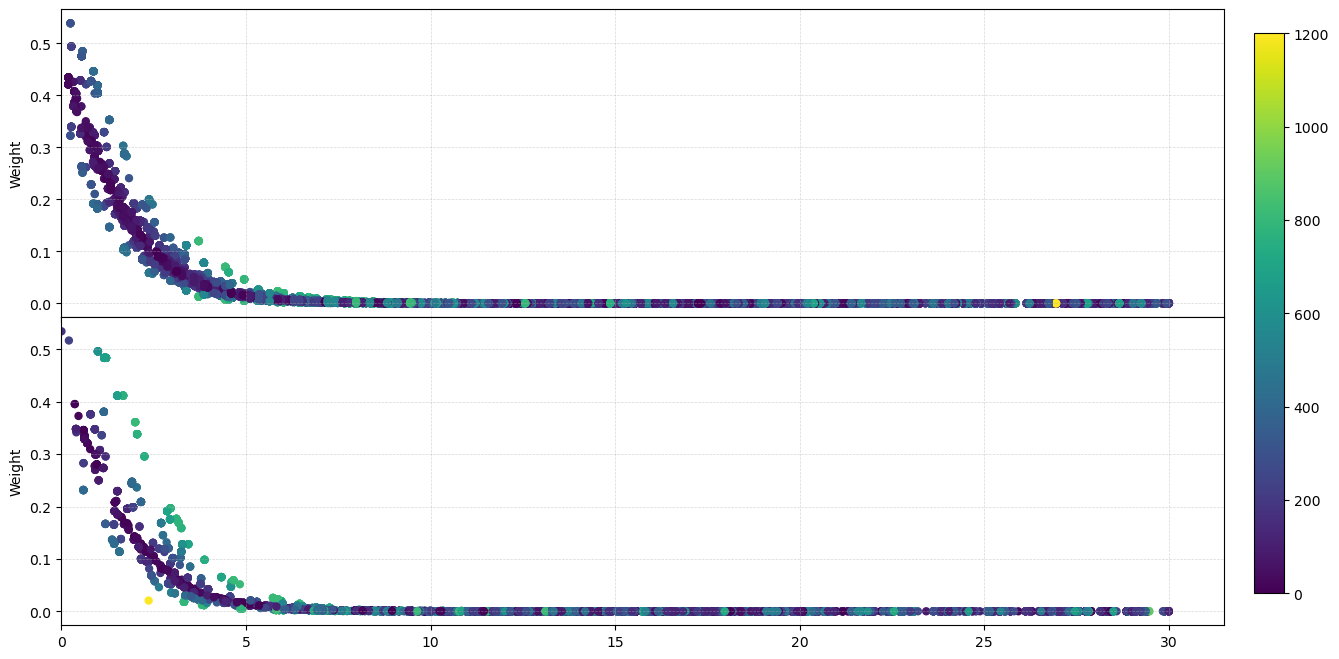

In [60]:
vmin, vmax = train_param_df.vs30_diff.min(), train_param_df.vs30_diff.max()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

cm = ax1.scatter(train_param_df.dist, train_results_df.w_avg, c=train_param_df.vs30_diff, cmap="viridis", s=25, vmin=vmin, vmax=vmax)
ax1.set_ylabel("Weight")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlim(0, None)

ax2.scatter(val_param_df.dist, val_results_df.w_avg, c=val_param_df.vs30_diff, cmap="viridis", s=25, vmin=vmin, vmax=vmax)
ax2.set_ylabel("Weight")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlim(0, None)

# Create a new axes for the colorbar at the right of the figure
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])

# Draw the colorbar in the new axes
fig.colorbar(cm, cax=cbar_ax)

plt.subplots_adjust(hspace=0)